# Predicting Colorectal Cancer Diagnosis — Modeling
**UC Berkeley AI/ML Professional Certificate — Capstone Project (Final Submission)**

---

## Overview
This notebook loads the raw BRFSS 2023 dataset, performs data preparation, and trains three machine learning models. See `colorectal_cancer_results.ipynb` for model comparison, equity analysis, and final recommendations.

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Preparation](#2-data-loading--preparation)
3. [Train/Test Split](#3-traintest-split)
4. [Model 1: Logistic Regression Baseline](#4-model-1-logistic-regression-baseline)
5. [Model 2: Random Forest with GridSearchCV](#5-model-2-random-forest-with-gridsearchcv)
6. [Model 3: Gradient Boosting with GridSearchCV](#6-model-3-gradient-boosting-with-gridsearchcv)
7. [ROC Curve Comparison](#7-roc-curve-comparison)

---
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Data Loading & Preparation

**Before running:** Place `LLCP2023.XPT` in the same folder as this notebook.  
Download from: https://www.cdc.gov/brfss/annual_data/annual_2023.html

In [2]:
# Load the BRFSS 2023 XPT file
# This may take 1-2 minutes due to file size (~64 MB zipped, larger unzipped)
DATA_PATH = '../data/LLCP2023.XPT'

print('Loading BRFSS 2023 dataset (this may take 2-3 minutes)...')
df_raw = pd.read_sas(DATA_PATH, format='xport', encoding='latin-1')
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns')

Loading BRFSS 2023 dataset (this may take 2-3 minutes)...
Dataset loaded: 433,323 rows, 350 columns


In [3]:
# Variable selection
VARIABLE_MAP = {
    'CHCSCNC1': 'colorectal_cancer',
    '_AGEG5YR': 'age_group',
    'SEXVAR':   'sex',
    '_RACEGR3': 'race_ethnicity',
    'INCOME3':  'income',
    'EDUCA':    'education',
    '_HLTHPL1': 'has_insurance',
    'MEDCOST1': 'cost_barrier',
    'CHECKUP1': 'last_checkup',
    'PERSDOC3': 'personal_doctor',
    'SMOKE100': 'smoker',
    '_BMI5CAT': 'bmi_category',
    'EXERANY2': 'exercise',
    'DRNKANY6': 'alcohol',
    '_STATE':   'state'
}
available_vars = [v for v in VARIABLE_MAP if v in df_raw.columns]
df = df_raw[available_vars].rename(columns=VARIABLE_MAP)
print(f'Variables selected: {len(available_vars)} | Working dataframe: {df.shape}')

Variables selected: 15 | Working dataframe: (433323, 15)


In [4]:
# Data cleaning
SENTINEL_CODES = [7, 9, 77, 99, 777, 999]
df.replace(SENTINEL_CODES, np.nan, inplace=True)

initial_rows = len(df)
df.dropna(subset=['colorectal_cancer'], inplace=True)
print(f'Rows dropped (missing target): {initial_rows - len(df):,} | Remaining: {len(df):,}')

df['colorectal_cancer'] = df['colorectal_cancer'].map({1: 1, 2: 0})
df['age_group'] = df['age_group'].replace(14, np.nan)
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)

EXCLUDE = ['colorectal_cancer', 'income', 'state']
for col in df.columns:
    if col in EXCLUDE:
        continue
    pct = df[col].isnull().mean() * 100
    if 0 < pct <= 20:
        df[col].fillna(df[col].mode()[0], inplace=True)

print('Data cleaning complete.')
print(f'Target distribution: {df["colorectal_cancer"].value_counts().to_dict()}')

Rows dropped (missing target): 2,930 | Remaining: 430,393
Data cleaning complete.
Target distribution: {0: 336267, 1: 33063}


In [5]:
# Feature engineering: Healthcare Access Index
df['access_index'] = (
    df['has_insurance'].map({1: 0, 2: 1}).fillna(0) +
    df['cost_barrier'].map({1: 1, 2: 0}).fillna(0) +
    df['last_checkup'].fillna(4) / 4
)

MODEL_FEATURES = [
    'age_group', 'sex', 'race_ethnicity', 'education',
    'has_insurance', 'cost_barrier', 'last_checkup', 'personal_doctor',
    'smoker', 'bmi_category', 'exercise', 'alcohol', 'access_index'
]
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df.columns]

model_df = df[MODEL_FEATURES + ['colorectal_cancer']].dropna()
X = model_df[MODEL_FEATURES]
y = model_df['colorectal_cancer']

print(f'Final modeling dataset: {X.shape[0]:,} rows, {X.shape[1]} features')
print(f'Features: {MODEL_FEATURES}')

Final modeling dataset: 369,330 rows, 13 features
Features: ['age_group', 'sex', 'race_ethnicity', 'education', 'has_insurance', 'cost_barrier', 'last_checkup', 'personal_doctor', 'smoker', 'bmi_category', 'exercise', 'alcohol', 'access_index']


---
## 3. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]:,} rows | positive rate: {y_train.mean()*100:.2f}%')
print(f'Test set:     {X_test.shape[0]:,} rows  | positive rate: {y_test.mean()*100:.2f}%')

Training set: 295,464 rows | positive rate: 8.95%
Test set:     73,866 rows  | positive rate: 8.95%


---
## 4. Model 1: Logistic Regression Baseline

Logistic Regression is our interpretable baseline. Coefficients translate directly to odds ratios readable by clinical audiences.

**Why ROC-AUC?** With ~8% positive class, accuracy is misleading. ROC-AUC measures the model's ability to rank high-risk individuals above low-risk ones across all thresholds.

In [7]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'CV AUC: {lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}')

lr_pipeline.fit(X_train, y_train)
lr_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pred       = lr_pipeline.predict(X_test)
lr_auc        = roc_auc_score(y_test, lr_pred_proba)

print(f'Test AUC: {lr_auc:.4f}')
print(classification_report(y_test, lr_pred, target_names=['No Diagnosis', 'Diagnosed']))

CV AUC: 0.7988 +/- 0.0025
Test AUC: 0.7996
              precision    recall  f1-score   support

No Diagnosis       0.97      0.63      0.76     67253
   Diagnosed       0.18      0.83      0.30      6613

    accuracy                           0.65     73866
   macro avg       0.58      0.73      0.53     73866
weighted avg       0.90      0.65      0.72     73866



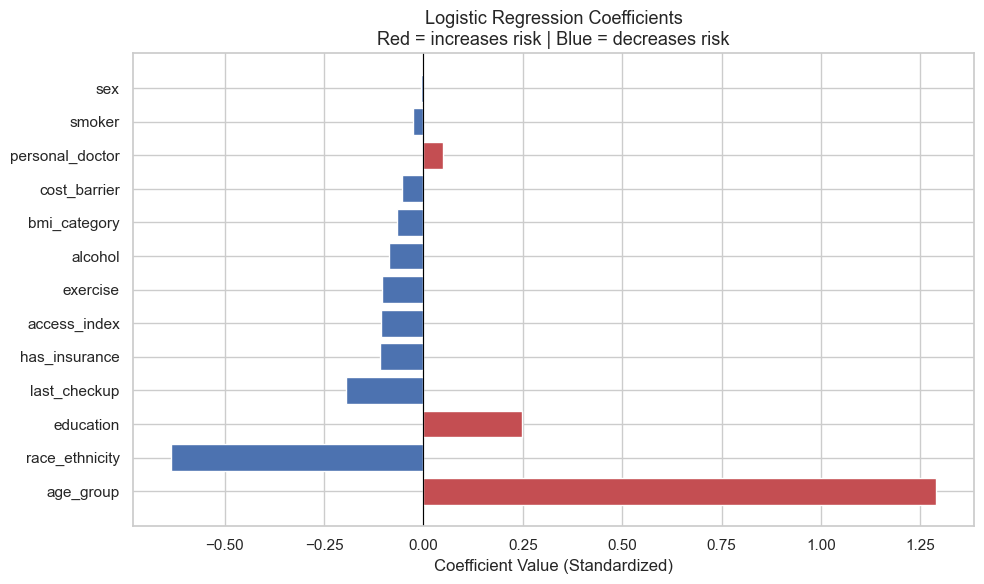

In [8]:
# Logistic Regression coefficients
coef_df = pd.DataFrame({
    'Feature':     MODEL_FEATURES,
    'Coefficient': lr_pipeline.named_steps['model'].coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\nRed = increases risk | Blue = decreases risk', fontsize=13)
ax.set_xlabel('Coefficient Value (Standardized)')
plt.tight_layout()
plt.show()

---
## 5. Model 2: Random Forest with GridSearchCV

Random Forest builds many decision trees and combines their predictions. It captures non-linear relationships that logistic regression cannot.

In [9]:
rf_param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 10],
    'max_features':      ['sqrt', 'log2'],
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=0
)

print('Running GridSearchCV for Random Forest...')
rf_grid_search.fit(X_train, y_train)
print(f'Best parameters: {rf_grid_search.best_params_}')
print(f'Best CV AUC:     {rf_grid_search.best_score_:.4f}')

Running GridSearchCV for Random Forest...
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Best CV AUC:     0.8103


In [10]:
rf_best       = rf_grid_search.best_estimator_
rf_pred_proba = rf_best.predict_proba(X_test)[:, 1]
rf_pred       = rf_best.predict(X_test)
rf_auc        = roc_auc_score(y_test, rf_pred_proba)

print(f'Best CV AUC: {rf_grid_search.best_score_:.4f} | Test AUC: {rf_auc:.4f}')
print(classification_report(y_test, rf_pred, target_names=['No Diagnosis', 'Diagnosed']))

Best CV AUC: 0.8103 | Test AUC: 0.8109
              precision    recall  f1-score   support

No Diagnosis       0.98      0.63      0.76     67253
   Diagnosed       0.18      0.86      0.30      6613

    accuracy                           0.65     73866
   macro avg       0.58      0.74      0.53     73866
weighted avg       0.91      0.65      0.72     73866



---
## 6. Model 3: Gradient Boosting with GridSearchCV

Gradient Boosting builds trees sequentially, each correcting errors of the previous one. Typically achieves the strongest predictive performance.

In [11]:
gb_param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'subsample':     [0.8, 1.0],
}

gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=0
)

print('Running GridSearchCV for Gradient Boosting...')
gb_grid_search.fit(X_train, y_train)
print(f'Best parameters: {gb_grid_search.best_params_}')
print(f'Best CV AUC:     {gb_grid_search.best_score_:.4f}')

Running GridSearchCV for Gradient Boosting...
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC:     0.8130


In [12]:
# Refit with sample weights to address class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_best = gb_grid_search.best_estimator_
gb_best.fit(X_train, y_train, sample_weight=sample_weights)

gb_pred_proba = gb_best.predict_proba(X_test)[:, 1]
gb_pred       = gb_best.predict(X_test)
gb_auc        = roc_auc_score(y_test, gb_pred_proba)

print(f'Best CV AUC: {gb_grid_search.best_score_:.4f} | Test AUC: {gb_auc:.4f}')
print(classification_report(y_test, gb_pred, target_names=['No Diagnosis', 'Diagnosed']))

Best CV AUC: 0.8130 | Test AUC: 0.8135
              precision    recall  f1-score   support

No Diagnosis       0.98      0.64      0.77     67253
   Diagnosed       0.19      0.85      0.31      6613

    accuracy                           0.66     73866
   macro avg       0.58      0.75      0.54     73866
weighted avg       0.91      0.66      0.73     73866



---
## 7. ROC Curve Comparison

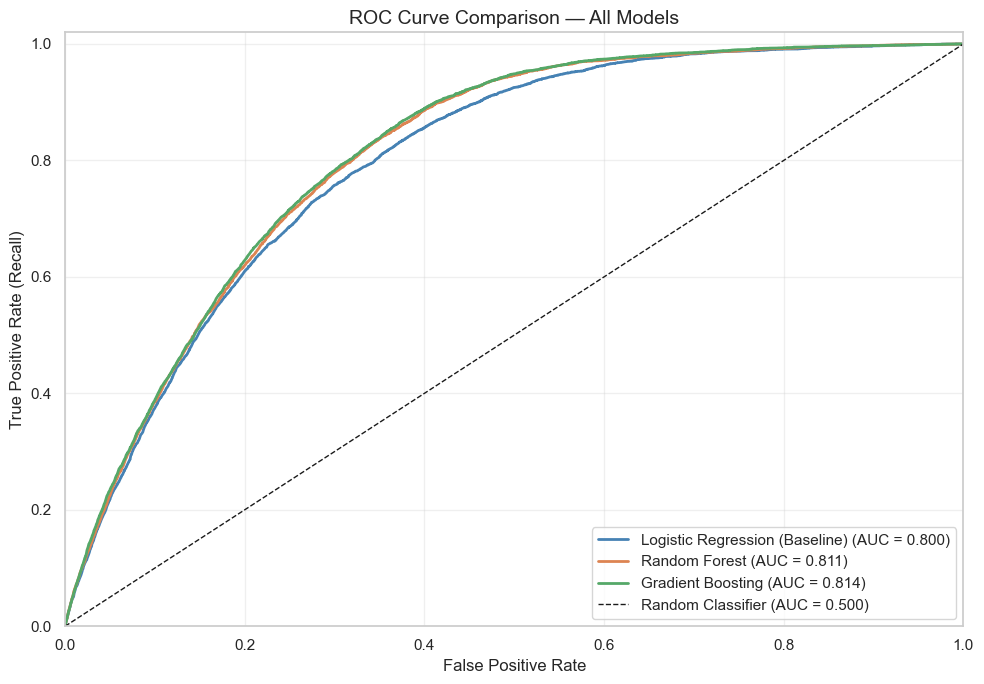

Model Comparison:
                           Model CV AUC  Test AUC  Precision  Recall     F1
  Logistic Regression (Baseline) 0.7988    0.7996     0.1799  0.8317 0.2959
    Random Forest (GridSearchCV) 0.8103    0.8109     0.1844  0.8592 0.3037
Gradient Boosting (GridSearchCV) 0.8130    0.8135     0.1891  0.8497 0.3093

Continue analysis in colorectal_cancer_results.ipynb


In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
for name, proba, auc, color in [
    ('Logistic Regression (Baseline)', lr_pred_proba, lr_auc, 'steelblue'),
    ('Random Forest',                  rf_pred_proba, rf_auc, '#DD8452'),
    ('Gradient Boosting',              gb_pred_proba, gb_auc, '#55A868'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
results = pd.DataFrame([
    {'Model': 'Logistic Regression (Baseline)', 'CV AUC': f'{lr_cv_scores.mean():.4f}', 'Test AUC': round(lr_auc, 4), 'Precision': round(precision_score(y_test, lr_pred), 4), 'Recall': round(recall_score(y_test, lr_pred), 4), 'F1': round(f1_score(y_test, lr_pred), 4)},
    {'Model': 'Random Forest (GridSearchCV)',    'CV AUC': f'{rf_grid_search.best_score_:.4f}', 'Test AUC': round(rf_auc, 4), 'Precision': round(precision_score(y_test, rf_pred), 4), 'Recall': round(recall_score(y_test, rf_pred), 4), 'F1': round(f1_score(y_test, rf_pred), 4)},
    {'Model': 'Gradient Boosting (GridSearchCV)', 'CV AUC': f'{gb_grid_search.best_score_:.4f}', 'Test AUC': round(gb_auc, 4), 'Precision': round(precision_score(y_test, gb_pred), 4), 'Recall': round(recall_score(y_test, gb_pred), 4), 'F1': round(f1_score(y_test, gb_pred), 4)},
])
print('Model Comparison:')
print(results.to_string(index=False))
print('\nContinue analysis in colorectal_cancer_results.ipynb')